# ASL Sign Language Recognition - MobileNetV2 Transfer Learning

Sử dụng **MobileNetV2** (pretrained trên ImageNet) làm feature extractor,
chỉ train phần classifier phía trên.

**Hướng dẫn:**
1. Vào **Settings → Accelerator → GPU T4 x2**
2. Bật **Internet** trong Settings (cần download pretrained weights)
3. Upload `Data.zip` lên Kaggle Dataset, add vào notebook
4. Chạy từng cell theo thứ tự

In [9]:
import os

# Config
#Gộp cả 2 folder data (landmark + non-landmark) vào cùng 1 thư mục DATA_DIR
# Cấu trúc: DATA_DIR/A/, DATA_DIR/B/, ... — mỗi class chứa ảnh từ cả 2 nguồn
DATA_DIR     = '/kaggle/input/datasets/kaizristo/biggest/data'   # <-- sửa nếu cần
OUTPUT_DIR   = '/kaggle/working'

IMG_SIZE     = 224      # MobileNetV2 optimal size
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-3
FINE_TUNE_LR = 1e-5

print(f'Data dir : {DATA_DIR}')
print(f'Classes  : {sorted(os.listdir(DATA_DIR))}')


Data dir : /kaggle/input/datasets/kaizristo/biggest/data
Classes  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [10]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

images = []
labels = []

class_names = sorted(os.listdir(DATA_DIR))
NUM_CLASSES  = len(class_names)

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    for file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, file)
        images.append(img_path)
        labels.append(idx)

images = np.array(images)
labels = np.array(labels)

print(f'Total images : {len(images)}')
print(f'Classes ({NUM_CLASSES}): {class_names}')


Total images : 30959
Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [11]:
# Split 70% train / 15% val / 15% test (test set độc lập, không dùng trong training)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    images, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,          # 50% của 30% = 15% tổng
    random_state=42,
    stratify=temp_labels
)

print(f'Train : {len(train_paths):,}')
print(f'Val   : {len(val_paths):,}')
print(f'Test  : {len(test_paths):,}')

# Lưu test paths/labels để dùng sau khi train xong
np.save(os.path.join(OUTPUT_DIR, 'test_paths.npy'),  test_paths)
np.save(os.path.join(OUTPUT_DIR, 'test_labels.npy'), test_labels)
print('Test split saved → test_paths.npy / test_labels.npy')


Train : 21,671
Val   : 4,644
Test  : 4,644
Test split saved → test_paths.npy / test_labels.npy


In [12]:
import tensorflow as tf

#load_image: KHÔNG chia /255 — model MobileNetV2 đã có Rescaling(1/127.5, offset=-1)
# Chỉ resize về IMG_SIZE và cast sang float32, giữ range [0, 255]
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)          # range [0, 255] — Rescaling layer trong model xử lý
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

train_ds = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
            .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(2000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds   = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
            .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds  = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
            .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

print('Datasets ready  ')


Datasets ready 


In [13]:
import collections
print('Train:', dict(sorted(collections.Counter(train_labels).items())))
print('Val  :', dict(sorted(collections.Counter(val_labels).items())))
print('Test :', dict(sorted(collections.Counter(test_labels).items())))


Train: {np.int64(0): 853, np.int64(1): 843, np.int64(2): 826, np.int64(3): 814, np.int64(4): 869, np.int64(5): 840, np.int64(6): 847, np.int64(7): 830, np.int64(8): 826, np.int64(9): 826, np.int64(10): 825, np.int64(11): 827, np.int64(12): 841, np.int64(13): 855, np.int64(14): 820, np.int64(15): 851, np.int64(16): 814, np.int64(17): 820, np.int64(18): 838, np.int64(19): 829, np.int64(20): 812, np.int64(21): 828, np.int64(22): 847, np.int64(23): 843, np.int64(24): 820, np.int64(25): 827}
Val  : {np.int64(0): 183, np.int64(1): 181, np.int64(2): 177, np.int64(3): 174, np.int64(4): 186, np.int64(5): 180, np.int64(6): 181, np.int64(7): 178, np.int64(8): 177, np.int64(9): 177, np.int64(10): 177, np.int64(11): 177, np.int64(12): 180, np.int64(13): 183, np.int64(14): 176, np.int64(15): 182, np.int64(16): 175, np.int64(17): 176, np.int64(18): 179, np.int64(19): 177, np.int64(20): 174, np.int64(21): 178, np.int64(22): 182, np.int64(23): 181, np.int64(24): 176, np.int64(25): 177}
Test : {np.int64

In [16]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from sklearn.utils.class_weight import compute_class_weight

#   Bắt buộc: xóa sạch graph cũ trước khi build model
# Tránh lỗi "expects 1 input but received 2" khi chạy lại cell
tf.keras.backend.clear_session()

# ── Load base model ──
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# ── Functional API — định nghĩa graph 1 lần duy nhất ──
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')

# Preprocessing: [0,255] → [-1,1] cho MobileNetV2
x = layers.Rescaling(1.0/127.5, offset=-1, name='rescaling')(inputs)

# Augmentation (chỉ active khi training=True)
x = layers.RandomFlip('horizontal', name='aug_flip')(x)
x = layers.RandomRotation(0.10, name='aug_rotate')(x)
x = layers.RandomZoom(0.15, name='aug_zoom')(x)
x = layers.RandomContrast(0.20, name='aug_contrast')(x)

# Feature extractor — gọi base_model MỘT LẦN DUY NHẤT
x = base_model(x, training=False)

# Classifier head
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dense(256, activation='relu', name='dense_256')(x)
x = layers.Dropout(0.4, name='drop_1')(x)
x = layers.Dense(128, activation='relu', name='dense_128')(x)
x = layers.Dropout(0.3, name='drop_2')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = tf.keras.Model(inputs, outputs, name='asl_mobilenet_v2')

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nTrainable params : {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}')
print(f'Frozen params    : {sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights):,}')

#   class_weight cân bằng landmark (ít) vs non-landmark (nhiều)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f'\nClass weights (sample): { {k: round(v,3) for k,v in list(class_weight_dict.items())[:5]} } ...')

# ── Phase 1: Train classifier, đóng băng base ──
callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_phase1.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    TensorBoard(log_dir='./logs/phase1', histogram_freq=1)
]

print('\n  Phase 1: Train classifier (base_model đóng băng)')
history1 = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1
)

print(f'\n  Phase 1 xong! Val Accuracy: {max(history1.history["val_accuracy"])*100:.2f}%')


Model: "asl_mobilenet_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_flip (RandomFlip)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_rotate (RandomRotation)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_zoom (RandomZoom)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_contrast (RandomContrast)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,170 (10.00 MB)

 Trainable params: 364,186 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params : 364,186
Frozen params    : 2,257,984

Class weights (sample): {0: np.float64(0.977), 1: np.float64(0.989), 2: np.float64(1.009), 3: np.float64(1.024), 4: np.float64(0.959)} ...

  Phase 1: Train classifier (base_model đóng băng)
Epoch 1/30
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3231 - loss: 2.2446
Epoch 1: val_accuracy improved from -inf to 0.59582, saving model to /kaggle/working/best_phase1.keras
678/678 ━━━━━━━━━━━━━━━━━━━━ 58s 76ms/step - accuracy: 0.3236 - loss: 2.2426 - val_accuracy: 0.5958 - val_loss: 1.2548 - learning_rate: 0.0010
Epoch 2/30
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7657 - loss: 0.7067
Epoch 2: val_accuracy improved from 0.59582 to 0.67937, saving model to /kaggle/working/best_phase1.keras
678/678 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.7658 - loss: 0.7064 - val_accuracy: 0.6794 - val_loss: 1.0270 - learning_rate: 0.0010
Epoch 3/30
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8590 - loss: 0.

In [ ]:
# Cell này đã được thay thế bởi cell trên (Functional API)
# Giữ lại để tham khảo — KHÔNG chạy cell này
print("   Bỏ qua cell này — dùng Functional API ở cell trên")


In [17]:
# Phase 2: Fine-tuning — mở 50 layers cuối
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Trainable params sau fine-tune: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}')

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_model.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    TensorBoard(log_dir='./logs/phase2', histogram_freq=1)
]

print('\n  Phase 2: Fine-tuning top 50 layers')
history2 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weight_dict,   #   giữ class_weight ở cả phase 2
    callbacks=callbacks_ft
)

print(f'\n  Fine-tuning xong! Val Accuracy: {max(history2.history["val_accuracy"])*100:.2f}%')


Trainable params sau fine-tune: 2,219,290

  Phase 2: Fine-tuning top 50 layers
Epoch 1/20
678/678 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6583 - loss: 1.1886
Epoch 1: val_accuracy improved from -inf to 0.74053, saving model to /kaggle/working/best_model.keras
678/678 ━━━━━━━━━━━━━━━━━━━━ 90s 110ms/step - accuracy: 0.6585 - loss: 1.1880 - val_accuracy: 0.7405 - val_loss: 0.8774 - learning_rate: 1.0000e-05
Epoch 2/20
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8689 - loss: 0.3899
Epoch 2: val_accuracy improved from 0.74053 to 0.76723, saving model to /kaggle/working/best_model.keras
678/678 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.8689 - loss: 0.3898 - val_accuracy: 0.7672 - val_loss: 0.7331 - learning_rate: 1.0000e-05
Epoch 3/20
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9114 - loss: 0.2670
Epoch 3: val_accuracy improved from 0.76723 to 0.78058, saving model to /kaggle/working/best_model.keras
678/678 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accur

In [18]:
# Lưu model & labels
model.save(os.path.join(OUTPUT_DIR, 'asl_model.keras'))
print('Model saved → asl_model.keras')

with open(os.path.join(OUTPUT_DIR, 'labels.txt'), 'w') as f:
    f.write('\n'.join(class_names))
print('Labels saved → labels.txt')


Model saved → asl_model.keras
Labels saved → labels.txt


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


ĐÁNH GIÁ TRÊN TEST SET ĐỘC LẬP (chưa từng thấy trong training)
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9082 - loss: 0.2970

Test Loss     : 0.3214
Test Accuracy : 90.74%
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           A       0.87      0.90      0.89       183
           B       0.95      0.98      0.97       180
           C       0.92      1.00      0.96       177
           D       0.92      0.95      0.94       174
           E       0.91      0.83      0.87       186
           F       0.88      0.94      0.91       180
           G       0.75      0.98      0.85       182
           H       0.99      0.80      0.89       178
           I       0.97      0.90      0.93       177
           J       0.93      0.98      0.95       177
           K       0.94      0.99      0.96       176
           L       0.93      0.99      0.96       177
           M       0.92   

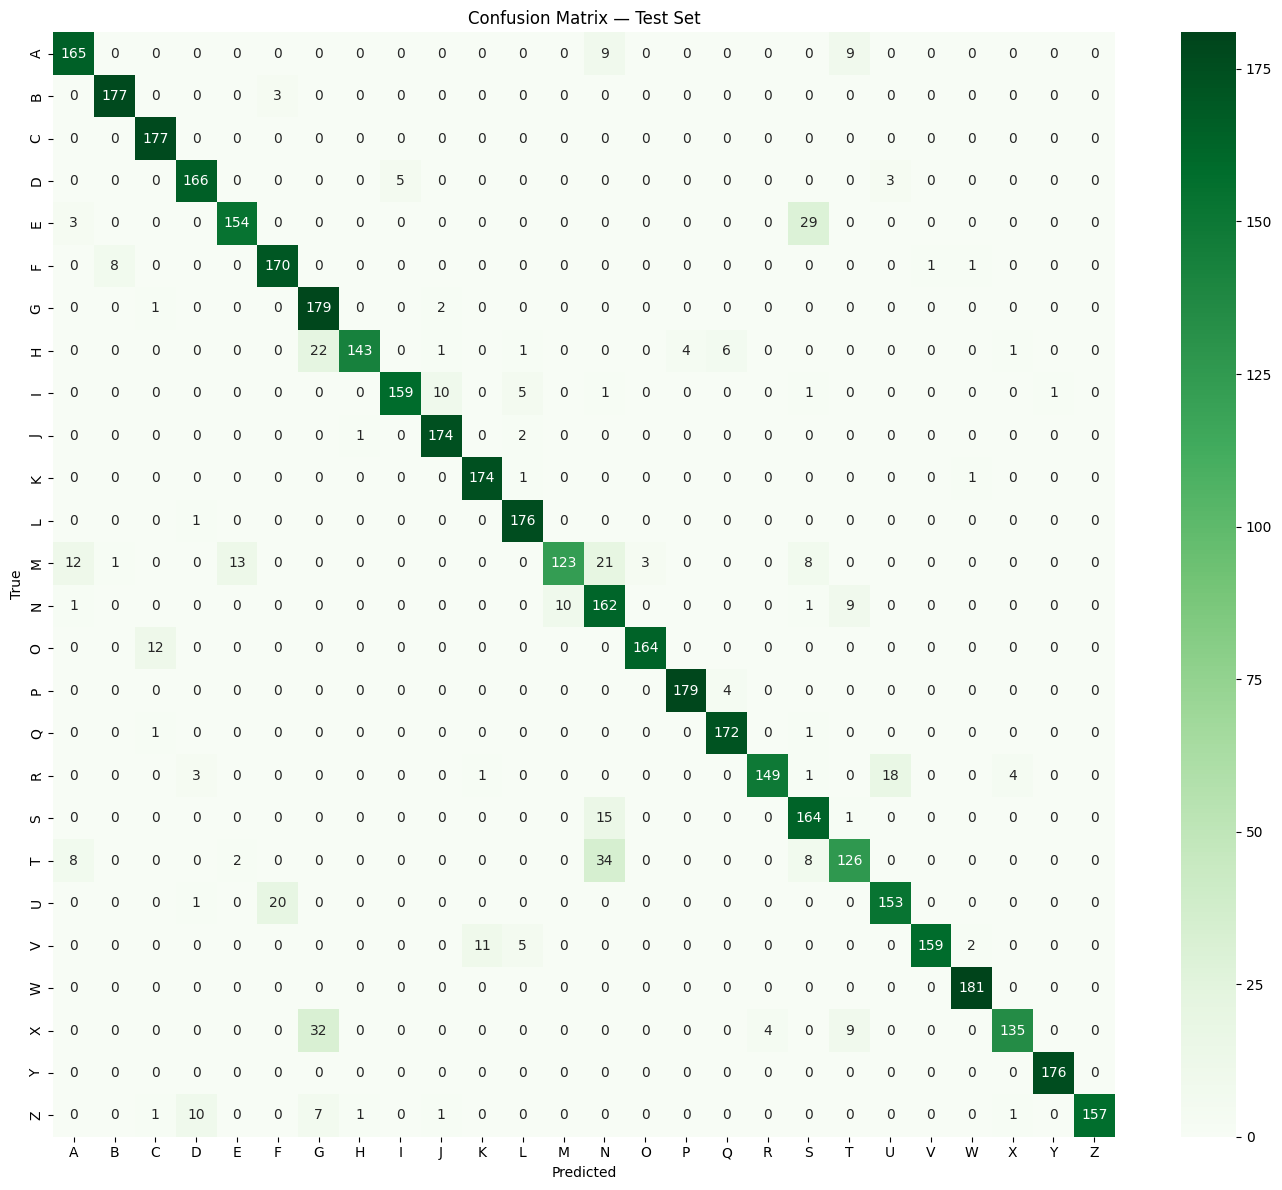

Saved → confusion_matrix_test.png


In [22]:
# ============================================================
#    ĐÁNH GIÁ TRÊN TEST SET ĐỘC LẬP
# ============================================================
print('\n' + '='*55)
print('ĐÁNH GIÁ TRÊN TEST SET ĐỘC LẬP (chưa từng thấy trong training)')
print('='*55)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc*100:.2f}%')

# Detailed report
test_preds = model.predict(test_ds, verbose=1)
test_pred_classes = np.argmax(test_preds, axis=1)

true_test_classes = []
for _, y in test_ds:
    true_test_classes.extend(np.argmax(y.numpy(), axis=1))
true_test_classes = np.array(true_test_classes)

print('\n--- Classification Report (Test Set) ---')
print(classification_report(true_test_classes, test_pred_classes, target_names=class_names))

# Confusion Matrix — Test Set
cm_test = confusion_matrix(true_test_classes, test_pred_classes)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_test.png'), dpi=120)
plt.show()
print('Saved → confusion_matrix_test.png')


In [23]:
# Lưu model & labels
model.save(os.path.join(OUTPUT_DIR, 'asl_model.keras'))
print('Model saved → asl_model.keras')

with open(os.path.join(OUTPUT_DIR, 'labels.txt'), 'w') as f:
    f.write('\n'.join(class_names))
print('Labels saved → labels.txt')

Model saved → asl_model.keras
Labels saved → labels.txt


##    Đánh giá Model

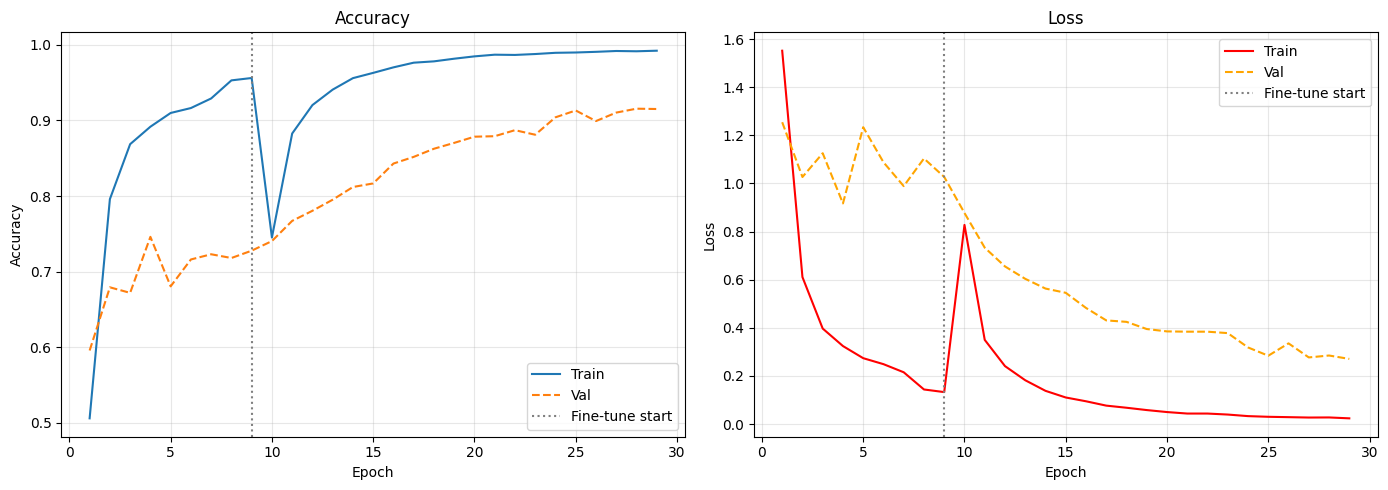

In [24]:
# Learning curves (cả 2 phases)
h1 = history1.history
h2 = history2.history

acc     = h1['accuracy']     + h2['accuracy']
val_acc = h1['val_accuracy'] + h2['val_accuracy']
loss    = h1['loss']         + h2['loss']
val_loss= h1['val_loss']     + h2['val_loss']
epochs_ran = range(1, len(acc) + 1)
phase1_end = len(h1['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, acc,     label='Train')
ax1.plot(epochs_ran, val_acc, label='Val', linestyle='--')
ax1.axvline(x=phase1_end, color='gray', linestyle=':', label='Fine-tune start')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, loss,     label='Train', color='r')
ax2.plot(epochs_ran, val_loss, label='Val',   color='orange', linestyle='--')
ax2.axvline(x=phase1_end, color='gray', linestyle=':', label='Fine-tune start')
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=120)
plt.show()

In [25]:
val_preds = model.predict(val_ds)
val_pred_classes = np.argmax(val_preds, axis=1)

true_classes = []
for _, y in val_ds:
    true_classes.extend(np.argmax(y.numpy(), axis=1))

true_classes = np.array(true_classes)

from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    val_pred_classes,
    target_names=class_names
))

146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step
              precision    recall  f1-score   support

           A       0.90      0.92      0.91       183
           B       0.93      0.98      0.96       181
           C       0.93      1.00      0.96       177
           D       0.95      0.97      0.96       174
           E       0.93      0.88      0.90       186
           F       0.89      0.94      0.92       180
           G       0.70      0.99      0.82       181
           H       1.00      0.83      0.90       178
           I       0.98      0.89      0.93       177
           J       0.92      0.99      0.95       177
           K       0.93      1.00      0.96       177
           L       0.92      1.00      0.96       177
           M       0.87      0.72      0.79       180
           N       0.73      0.89      0.80       183
           O       0.98      0.94      0.96       176
           P       0.99      0.98      0.98       182
           Q       0.97      0.99      

In [26]:
print("Unique true classes:", np.unique(true_classes))
print("Unique predicted:", np.unique(val_pred_classes))

Unique true classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Unique predicted: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


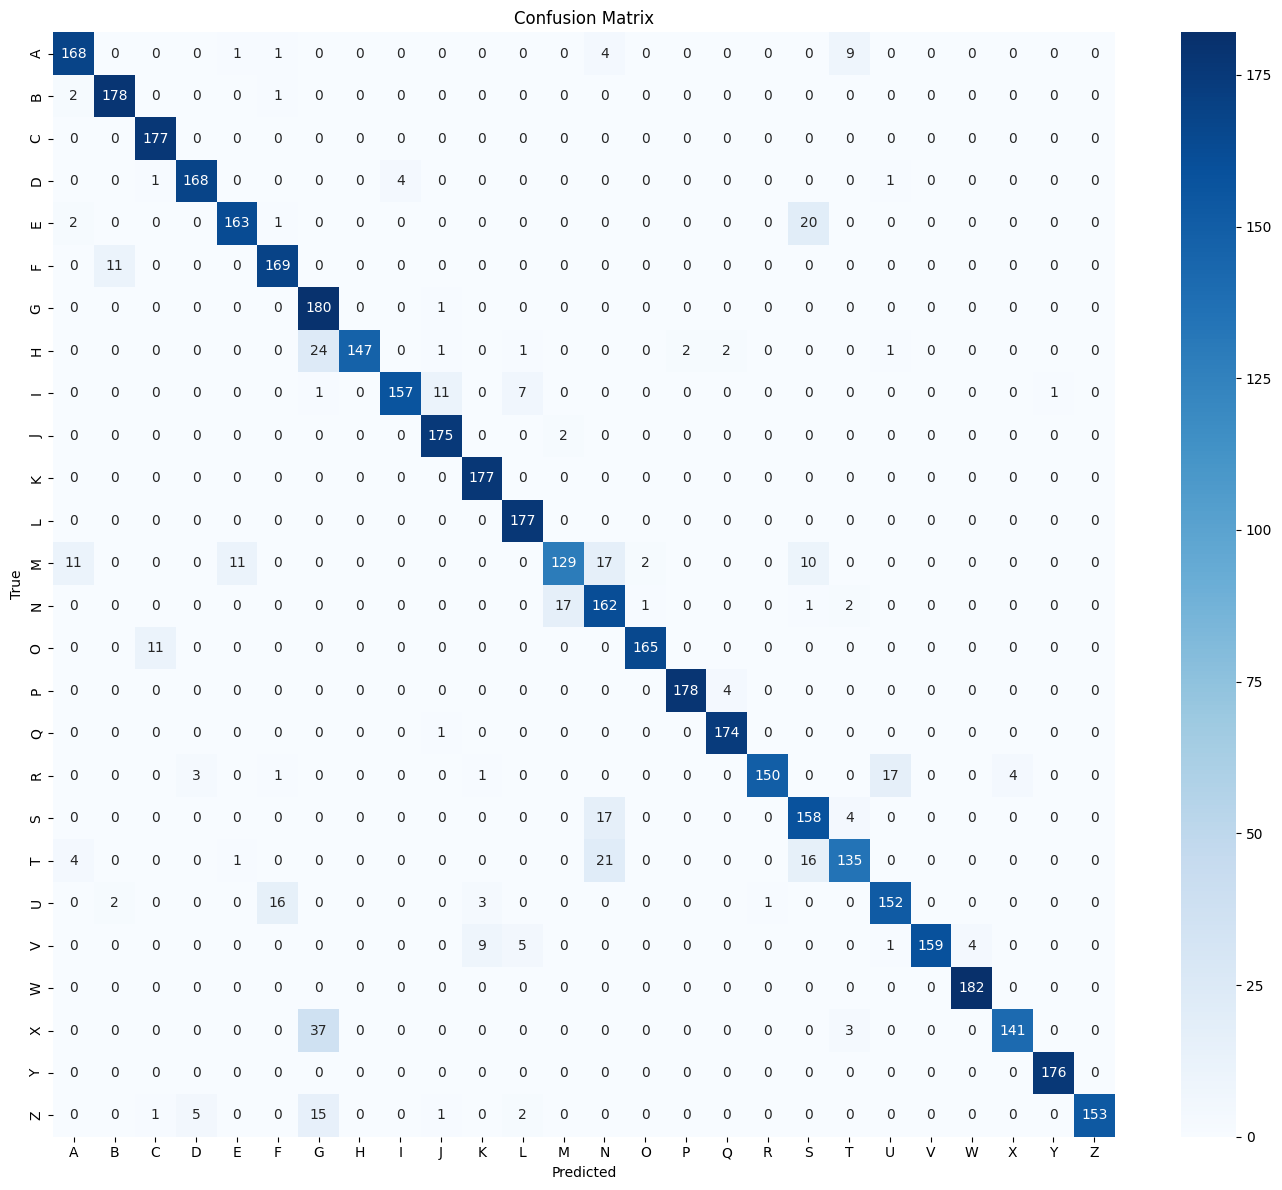

In [27]:
# Confusion Matrix
cm = confusion_matrix(true_classes, val_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

In [28]:
# Tóm tắt kết quả
best_val_acc = max(val_acc)
final_train_acc = acc[-1]
final_val_acc = val_acc[-1]
gap = final_train_acc - final_val_acc

print('=' * 50)
print('KẾT QUẢ HUẤN LUYỆN (MobileNetV2)')
print('=' * 50)
print(f'Training Accuracy:   {final_train_acc*100:.2f}%')
print(f'Validation Accuracy: {final_val_acc*100:.2f}%')
print(f'Best Val Accuracy:   {best_val_acc*100:.2f}%')
print(f'Overfitting gap:     {gap*100:.2f}%')
print()
if gap < 0.05:
    print('  Model tốt! Gap < 5%')
elif gap < 0.10:
    print('  Overfitting nhẹ (5-10%)')
else:
    print('  Overfitting nặng (>10%)')

KẾT QUẢ HUẤN LUYỆN (MobileNetV2)
Training Accuracy:   99.22%
Validation Accuracy: 91.52%
Best Val Accuracy:   91.56%
Overfitting gap:     7.71%

  Overfitting nhẹ (5-10%)


##     Download kết quả

Vào tab **Output** (góc phải) để download:
- `asl_model.keras` — model MobileNetV2 đã train
- `labels.txt` — danh sách classes
- `best_model.keras` — checkpoint tốt nhất
- `learning_curves.png` / `confusion_matrix.png`

Đặt `asl_model.keras` và `labels.txt` vào thư mục `Model/` trong project.